# Heart Failure Clinical Records — Classification Assignment

**Objective:** Predict patient mortality during the follow-up period (`DEATH_EVENT`) using
clinical records from patients who had heart failure, based on the Heart Failure Clinical
Records dataset.

**Pipeline:**
1. Data Loading & Exploration (EDA)
2. Missing Value Handling
3. Encoding (if required)
4. Train-Test Split
5. Feature Scaling
6. Handling Class Imbalance (SMOTE)
7. Model Training (8 classification models)
8. Model Evaluation & Comparison
9. Best Model Selection
10. Hyperparameter Tuning (GridSearchCV)
11. Final Evaluation
12. Feature Importance
13. Conclusion


## 1. Import Libraries

In [1]:
# Core libraries
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style('whitegrid')

# Preprocessing
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import NearestNeighbors

# Classification models
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier
from sklearn.naive_bayes import GaussianNB

# Evaluation metrics
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                              roc_auc_score, roc_curve, confusion_matrix, classification_report)

RANDOM_STATE = 42
print("Libraries imported successfully.")

Libraries imported successfully.


## 2. Load Dataset

The Heart Failure Clinical Records dataset contains medical records of 299 patients who had
heart failure, collected during their follow-up period. The target column `DEATH_EVENT`
indicates whether the patient died during the follow-up period (1) or survived (0).


In [2]:
# Load the dataset
df = pd.read_csv('heart_failure_clinical_records_dataset.csv')

# Basic overview
print("Shape of dataset:", df.shape)
df.head()

Shape of dataset: (299, 13)


,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,time,DEATH_EVENT
0,75.0,0,582,0,20,1,265000.00,1.9,130,1,0,4,1
1,55.0,0,7861,0,38,0,263358.03,1.1,136,1,0,6,1
2,65.0,0,146,0,20,0,162000.00,1.3,129,1,1,7,1
3,50.0,1,111,0,20,0,210000.00,1.9,137,1,0,7,1
4,65.0,1,160,1,20,0,327000.00,2.7,116,0,0,8,1


In [3]:
# Data types and non-null counts
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 299 entries, 0 to 298
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   age                       299 non-null    float64
 1   anaemia                   299 non-null    int64  
 2   creatinine_phosphokinase  299 non-null    int64  
 3   diabetes                  299 non-null    int64  
 4   ejection_fraction         299 non-null    int64  
 5   high_blood_pressure       299 non-null    int64  
 6   platelets                 299 non-null    float64
 7   serum_creatinine          299 non-null    float64
 8   serum_sodium              299 non-null    int64  
 9   sex                       299 non-null    int64  
 10  smoking                   299 non-null    int64  
 11  time                      299 non-null    int64  
 12  DEATH_EVENT               299 non-null    int64  
dtypes: float64(3), int64(10)
memory usage: 30.5 KB


In [4]:
# Statistical summary of numerical columns
df.describe()

,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,time,DEATH_EVENT
count,299.000000,299.000000,299.000000,299.000000,299.000000,299.000000,299.000000,299.00000,299.000000,299.000000,299.00000,299.000000,299.00000
mean,60.833893,0.431438,581.839465,0.418060,38.083612,0.351171,263358.029264,1.39388,136.625418,0.648829,0.32107,130.260870,0.32107
std,11.894809,0.496107,970.287881,0.494067,11.834841,0.478136,97804.236869,1.03451,4.412477,0.478136,0.46767,77.614208,0.46767
min,40.000000,0.000000,23.000000,0.000000,14.000000,0.000000,25100.000000,0.50000,113.000000,0.000000,0.00000,4.000000,0.00000
25%,51.000000,0.000000,116.500000,0.000000,30.000000,0.000000,212500.000000,0.90000,134.000000,0.000000,0.00000,73.000000,0.00000
50%,60.000000,0.000000,250.000000,0.000000,38.000000,0.000000,262000.000000,1.10000,137.000000,1.000000,0.00000,115.000000,0.00000
75%,70.000000,1.000000,582.000000,1.000000,45.000000,1.000000,303500.000000,1.40000,140.000000,1.000000,1.00000,203.000000,1.00000
max,95.000000,1.000000,7861.000000,1.000000,80.000000,1.000000,850000.000000,9.40000,148.000000,1.000000,1.00000,285.000000,1.00000


## 3. Exploratory Data Analysis (EDA)

### 3.1 Check Missing Values

In [5]:
# Count and percentage of missing values per column
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
missing_df = missing_df.sort_values('Missing %', ascending=False)
missing_df

,Missing Count,Missing %
age,0,0.0
anaemia,0,0.0
creatinine_phosphokinase,0,0.0
diabetes,0,0.0
ejection_fraction,0,0.0
high_blood_pressure,0,0.0
platelets,0,0.0
serum_creatinine,0,0.0
serum_sodium,0,0.0
sex,0,0.0


In [6]:
# No missing values were found -- confirm explicitly
print("Total missing values in dataset:", df.isnull().sum().sum())

Total missing values in dataset: 0


### 3.2 Target Variable Distribution (Class Imbalance Check)

DEATH_EVENT
0    203
1     96
Name: count, dtype: int64

Class proportions:
DEATH_EVENT
0    67.892977
1    32.107023
Name: proportion, dtype: float64


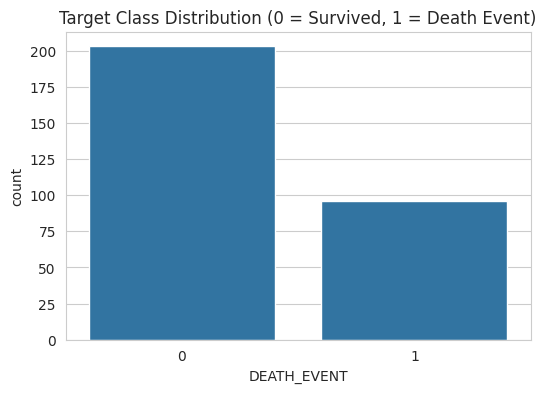

In [7]:
# Check class distribution of the target variable
target_counts = df['DEATH_EVENT'].value_counts()
print(target_counts)
print("\nClass proportions:")
print(df['DEATH_EVENT'].value_counts(normalize=True) * 100)

plt.figure(figsize=(6, 4))
sns.countplot(x='DEATH_EVENT', data=df)
plt.title('Target Class Distribution (0 = Survived, 1 = Death Event)')
plt.xlabel('DEATH_EVENT')
plt.show()

# The dataset is moderately IMBALANCED: about 68% survived (0) vs 32% death events (1)

### 3.3 Feature Distributions

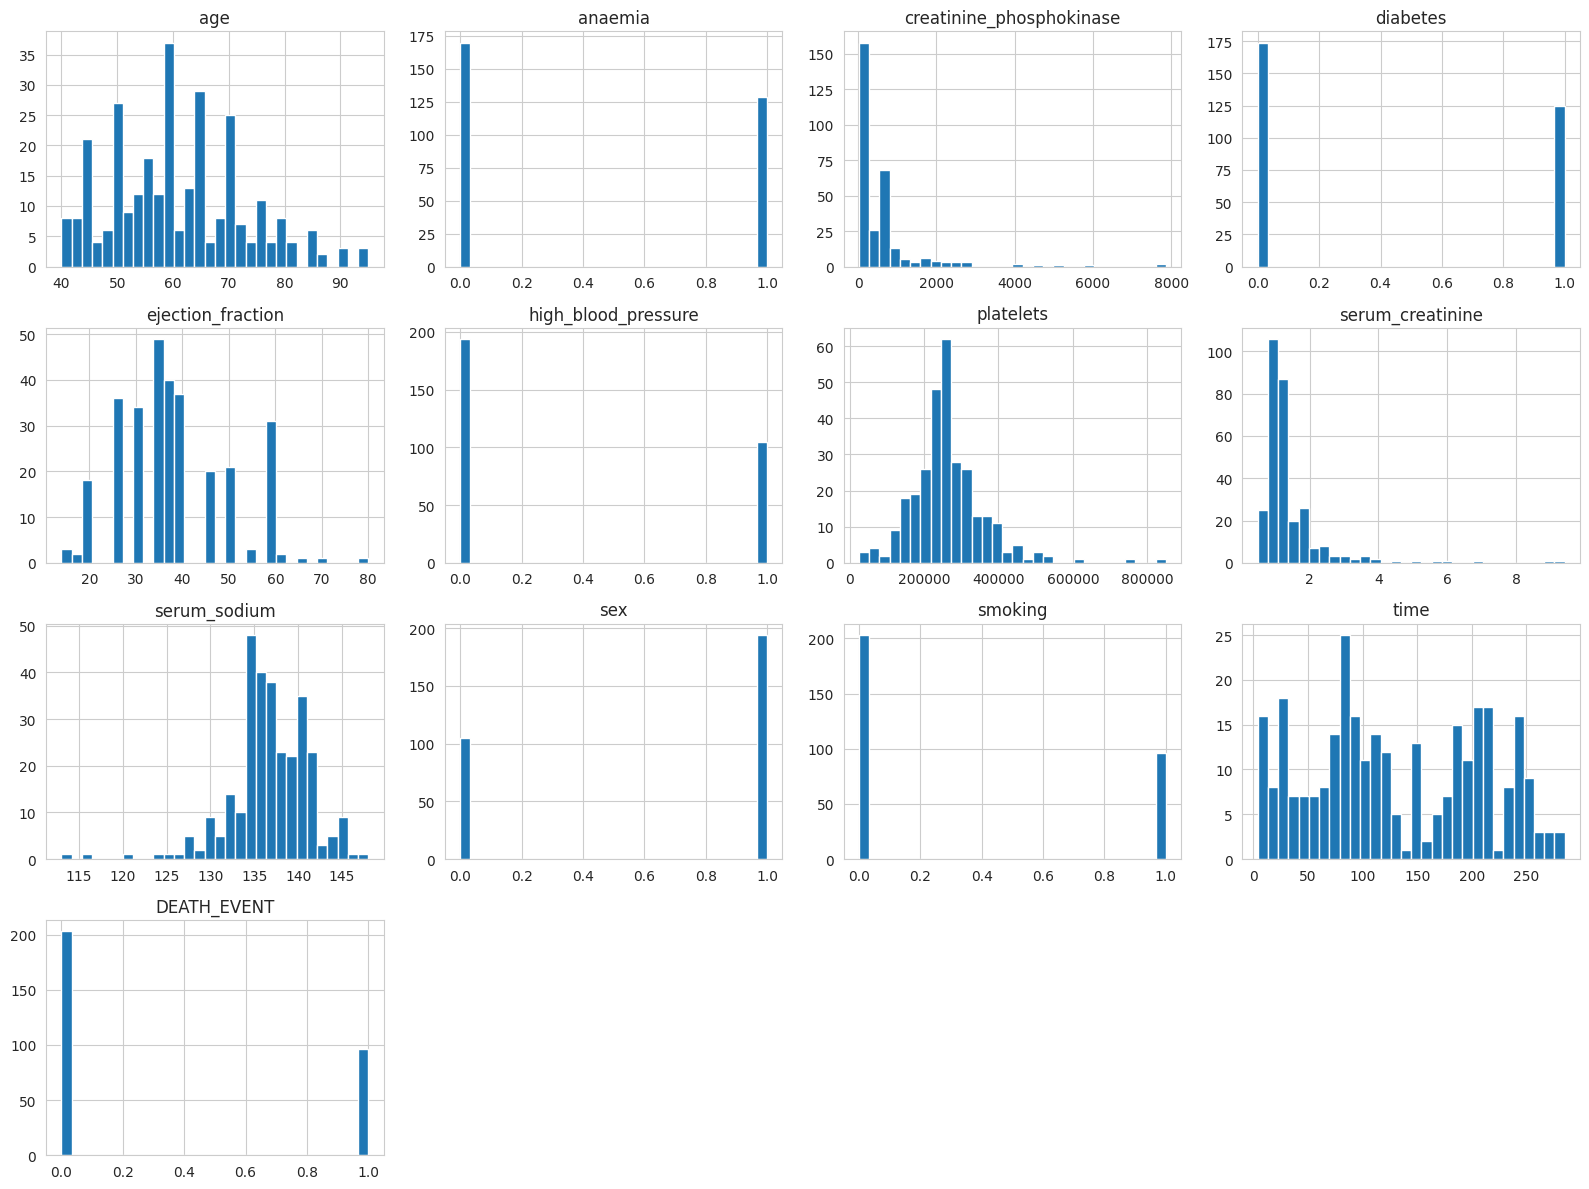

In [8]:
# Histograms for all numeric features
df.hist(figsize=(16, 12), bins=30)
plt.tight_layout()
plt.show()

### 3.4 Correlation Analysis

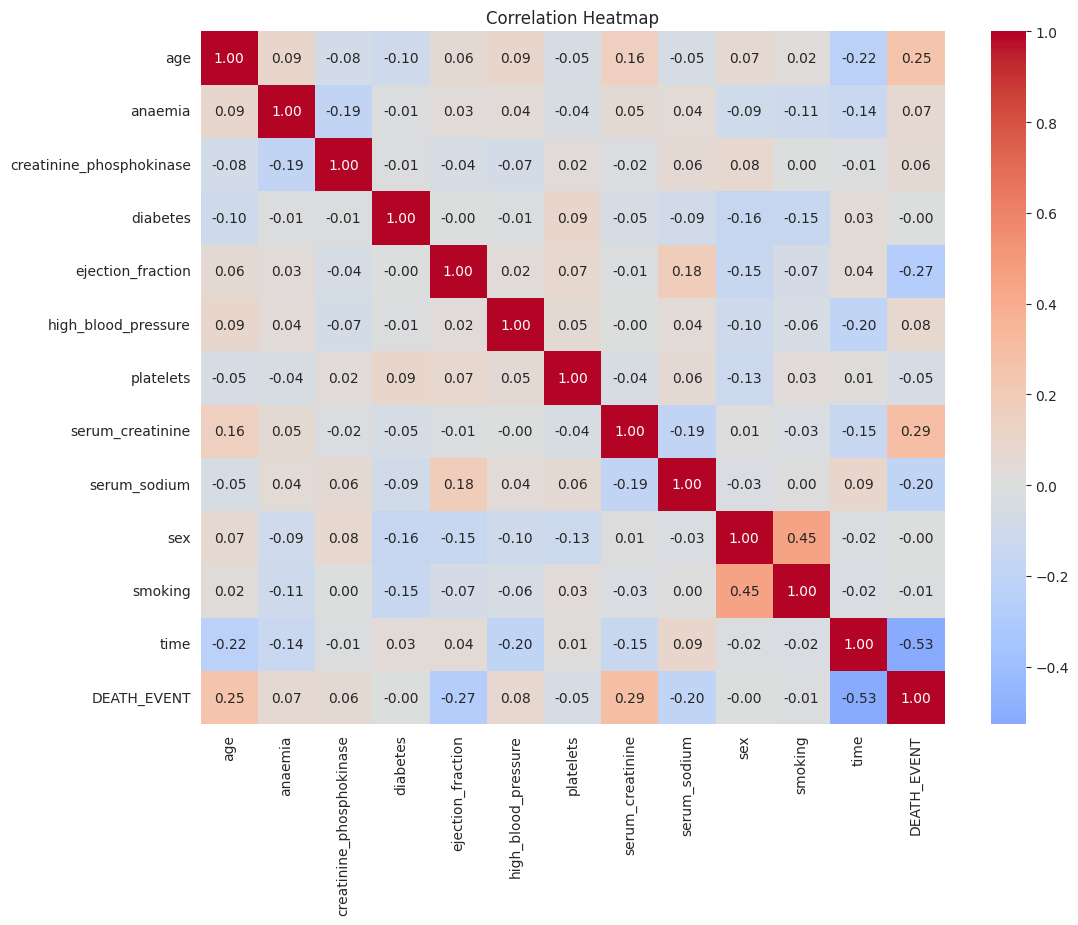

DEATH_EVENT                 1.000000
serum_creatinine            0.294278
age                         0.253729
high_blood_pressure         0.079351
anaemia                     0.066270
creatinine_phosphokinase    0.062728
diabetes                   -0.001943
sex                        -0.004316
smoking                    -0.012623
platelets                  -0.049139
serum_sodium               -0.195204
ejection_fraction          -0.268603
time                       -0.526964
Name: DEATH_EVENT, dtype: float64


In [9]:
# Correlation heatmap to understand relationships between features and the target
plt.figure(figsize=(12, 9))
corr = df.corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation Heatmap')
plt.show()

# Correlation of each feature with the target, sorted
print(corr['DEATH_EVENT'].sort_values(ascending=False))

### 3.5 Outlier Check (Boxplots)

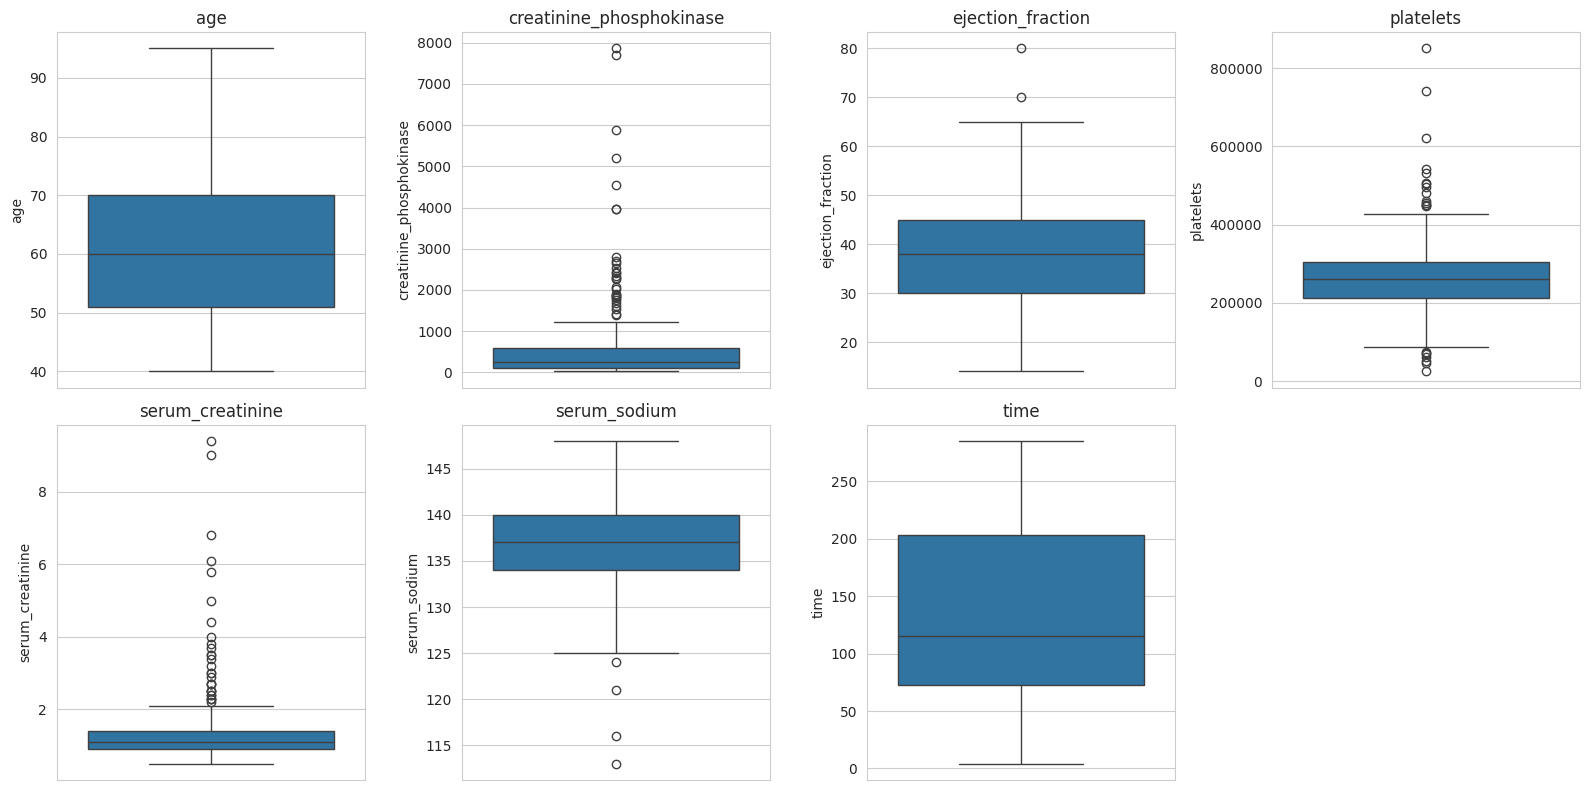

In [10]:
# Boxplots to visually inspect outliers in key continuous features
continuous_cols = ['age', 'creatinine_phosphokinase', 'ejection_fraction', 'platelets',
                    'serum_creatinine', 'serum_sodium', 'time']

plt.figure(figsize=(16, 8))
for i, col in enumerate(continuous_cols, 1):
    plt.subplot(2, 4, i)
    sns.boxplot(y=df[col])
    plt.title(col)
plt.tight_layout()
plt.show()

# Note: creatinine_phosphokinase, platelets and serum_creatinine show clear outliers
# (right-skewed lab values), which is clinically expected -- they are kept as-is since
# tree-based models are robust to them and scaling handles the linear models.

## 4. Handling Missing Values

As confirmed above, this dataset has **zero missing values** in any column, so no
imputation is required. This step is still included (as a check) to keep the pipeline
general and reusable for datasets that do have missing values.


In [11]:
# General-purpose missing value handling (kept for completeness / reusability),
# even though this dataset has no missing values.
for col in df.columns:
    if df[col].isnull().sum() > 0:
        if df[col].dtype in ['float64', 'int64']:
            df[col] = df[col].fillna(df[col].median())
        else:
            df[col] = df[col].fillna(df[col].mode()[0])

print("Missing values remaining:", df.isnull().sum().sum())

Missing values remaining: 0


## 5. Encoding

All columns in this dataset are already numeric: continuous lab measurements
(`age`, `creatinine_phosphokinase`, `ejection_fraction`, `platelets`, `serum_creatinine`,
`serum_sodium`, `time`) and binary flags (`anaemia`, `diabetes`, `high_blood_pressure`,
`sex`, `smoking`, `DEATH_EVENT`). **No categorical encoding is required** since there are
no text/object columns.


In [12]:
# Confirm all columns are numeric (no encoding needed)
print(df.dtypes.value_counts())
assert df.select_dtypes(include='object').shape[1] == 0, "There are non-numeric columns!"
print("All columns are numeric -- no encoding required.")

int64      10
float64     3
Name: count, dtype: int64
All columns are numeric -- no encoding required.


## 6. Feature-Target Split & Train-Test Split

We split the data BEFORE scaling and BEFORE balancing to avoid **data leakage**
(the scaler and SMOTE must only ever "see" the training data).


In [13]:
# Separate features and target
X = df.drop('DEATH_EVENT', axis=1)
y = df['DEATH_EVENT']

# Stratified train-test split to preserve class ratio in both sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

print("Train shape:", X_train.shape, " Test shape:", X_test.shape)
print("\nTrain target distribution:\n", y_train.value_counts(normalize=True))
print("\nTest target distribution:\n", y_test.value_counts(normalize=True))

Train shape: (239, 12)  Test shape: (60, 12)

Train target distribution:
 DEATH_EVENT
0    0.677824
1    0.322176
Name: proportion, dtype: float64

Test target distribution:
 DEATH_EVENT
0    0.683333
1    0.316667
Name: proportion, dtype: float64


## 7. Feature Scaling

Features are on very different scales (e.g. `platelets` in the hundreds of thousands vs
binary flags like `sex`). We apply `StandardScaler`, fitting **only on the training set**
and transforming both train and test sets with that same fitted scaler (prevents leakage).


In [14]:
# Fit scaler on training data only, then transform both train & test
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Convert back to DataFrame for readability
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns, index=X_test.index)

X_train_scaled.head()

,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,time
115,-0.269050,1.110696,-0.200735,-0.900337,0.176528,-0.770281,-1.004722,-0.360437,0.559915,-1.333818,-0.682831,-0.467847
23,-0.706883,-0.900337,-0.534318,1.110696,1.847425,-0.770281,1.051685,-0.544467,-0.345802,0.749728,-0.682831,-1.359167
0,1.219579,-0.900337,-0.020580,-0.900337,-1.494369,1.298227,0.013401,0.467698,-1.477949,0.749728,-0.682831,-1.591685
247,0.256348,-0.900337,-0.455129,-0.900337,-1.076645,-0.770281,-0.178127,0.927773,-0.345802,0.749728,-0.682831,1.121028
194,-1.407414,-0.900337,-0.020580,-0.900337,-1.494369,1.298227,-1.387778,0.191653,-0.345802,0.749728,-0.682831,0.681827


## 8. Handling Class Imbalance

The target is moderately imbalanced (~68% survived, ~32% death events). We balance the
**training set only** using **SMOTE** (Synthetic Minority Over-sampling Technique).

> The `imbalanced-learn` package is not always available in every environment, so this
> notebook includes a small, dependency-free implementation of SMOTE (k-NN based
> interpolation between minority-class samples) built directly on `scikit-learn`'s
> `NearestNeighbors`. If `imbalanced-learn` is installed, `from imblearn.over_sampling
> import SMOTE` works as a drop-in replacement and produces the same idea.


Before SMOTE: {0: 162, 1: 77}
After SMOTE : {0: 162, 1: 162}


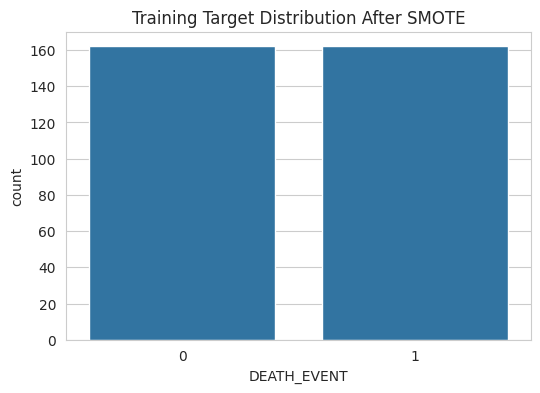

In [15]:
def smote_oversample(X, y, k_neighbors=5, random_state=42):
    """Minimal SMOTE implementation: for each minority-class sample, pick one of its
    k nearest minority-class neighbors and create a synthetic sample by interpolating
    between the two, until both classes have an equal number of samples."""
    rng = np.random.RandomState(random_state)
    X = np.asarray(X)
    y = np.asarray(y)

    classes, counts = np.unique(y, return_counts=True)
    majority_class = classes[np.argmax(counts)]
    minority_class = classes[np.argmin(counts)]
    n_majority = counts.max()
    n_minority = counts.min()
    n_to_generate = n_majority - n_minority

    X_min = X[y == minority_class]
    nn = NearestNeighbors(n_neighbors=min(k_neighbors + 1, len(X_min))).fit(X_min)
    _, neighbor_idx = nn.kneighbors(X_min)

    synthetic_samples = []
    for _ in range(n_to_generate):
        i = rng.randint(0, len(X_min))
        possible_neighbors = neighbor_idx[i][1:]  # exclude the point itself
        j = possible_neighbors[rng.randint(0, len(possible_neighbors))]
        gap = rng.rand()
        synthetic = X_min[i] + gap * (X_min[j] - X_min[i])
        synthetic_samples.append(synthetic)

    X_synthetic = np.array(synthetic_samples)
    y_synthetic = np.full(len(X_synthetic), minority_class)

    X_resampled = np.vstack([X, X_synthetic])
    y_resampled = np.concatenate([y, y_synthetic])
    return X_resampled, y_resampled


# Apply SMOTE only on the training data (never on test data!)
X_train_sm_arr, y_train_sm_arr = smote_oversample(X_train_scaled.values, y_train.values,
                                                    k_neighbors=5, random_state=RANDOM_STATE)
X_train_sm = pd.DataFrame(X_train_sm_arr, columns=X_train.columns)
y_train_sm = pd.Series(y_train_sm_arr, name='DEATH_EVENT')

print("Before SMOTE:", y_train.value_counts().to_dict())
print("After SMOTE :", y_train_sm.value_counts().to_dict())

plt.figure(figsize=(6, 4))
sns.countplot(x=y_train_sm)
plt.title('Training Target Distribution After SMOTE')
plt.xlabel('DEATH_EVENT')
plt.show()

## 9. Train Multiple Classification Models

We train 8 classification models on the SMOTE-balanced training data:
1. Logistic Regression
2. K-Nearest Neighbors
3. Support Vector Machine (SVM)
4. Decision Tree
5. Random Forest
6. Gradient Boosting
7. AdaBoost
8. Gaussian Naive Bayes


In [16]:
# Define the models to compare
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    'K-Nearest Neighbors': KNeighborsClassifier(),
    'Support Vector Machine': SVC(probability=True, random_state=RANDOM_STATE),
    'Decision Tree': DecisionTreeClassifier(random_state=RANDOM_STATE),
    'Random Forest': RandomForestClassifier(random_state=RANDOM_STATE),
    'Gradient Boosting': GradientBoostingClassifier(random_state=RANDOM_STATE),
    'AdaBoost': AdaBoostClassifier(random_state=RANDOM_STATE),
    'Naive Bayes': GaussianNB()
}

# Train every model on the SMOTE-balanced training data
trained_models = {}
for name, model in models.items():
    model.fit(X_train_sm, y_train_sm)
    trained_models[name] = model
    print(f"Trained: {name}")

Trained: Logistic Regression
Trained: K-Nearest Neighbors
Trained: Support Vector Machine
Trained: Decision Tree
Trained: Random Forest
Trained: Gradient Boosting
Trained: AdaBoost
Trained: Naive Bayes


## 10. Model Evaluation & Comparison

For each model, we evaluate on the **untouched, original-distribution test set**
(no SMOTE applied to test data -- evaluation must reflect real-world class distribution).

Metrics: Accuracy, Precision, Recall, F1-Score, ROC-AUC, Confusion Matrix, Classification Report.


In [17]:
results = []

for name, model in trained_models.items():
    y_pred = model.predict(X_test_scaled)
    y_proba = model.predict_proba(X_test_scaled)[:, 1] if hasattr(model, 'predict_proba') else None

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_proba) if y_proba is not None else np.nan

    results.append({'Model': name, 'Accuracy': acc, 'Precision': prec,
                     'Recall': rec, 'F1-Score': f1, 'ROC-AUC': auc})

results_df = pd.DataFrame(results).sort_values('F1-Score', ascending=False).reset_index(drop=True)
results_df

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Decision Tree,0.833333,0.764706,0.684211,0.722222,0.793325
1,Gradient Boosting,0.816667,0.700000,0.736842,0.717949,0.866496
2,Random Forest,0.800000,0.705882,0.631579,0.666667,0.897946
3,Logistic Regression,0.816667,0.785714,0.578947,0.666667,0.845956
4,Naive Bayes,0.750000,0.625000,0.526316,0.571429,0.813864
5,Support Vector Machine,0.733333,0.588235,0.526316,0.555556,0.851091
6,AdaBoost,0.733333,0.588235,0.526316,0.555556,0.824134
7,K-Nearest Neighbors,0.750000,0.642857,0.473684,0.545455,0.813864


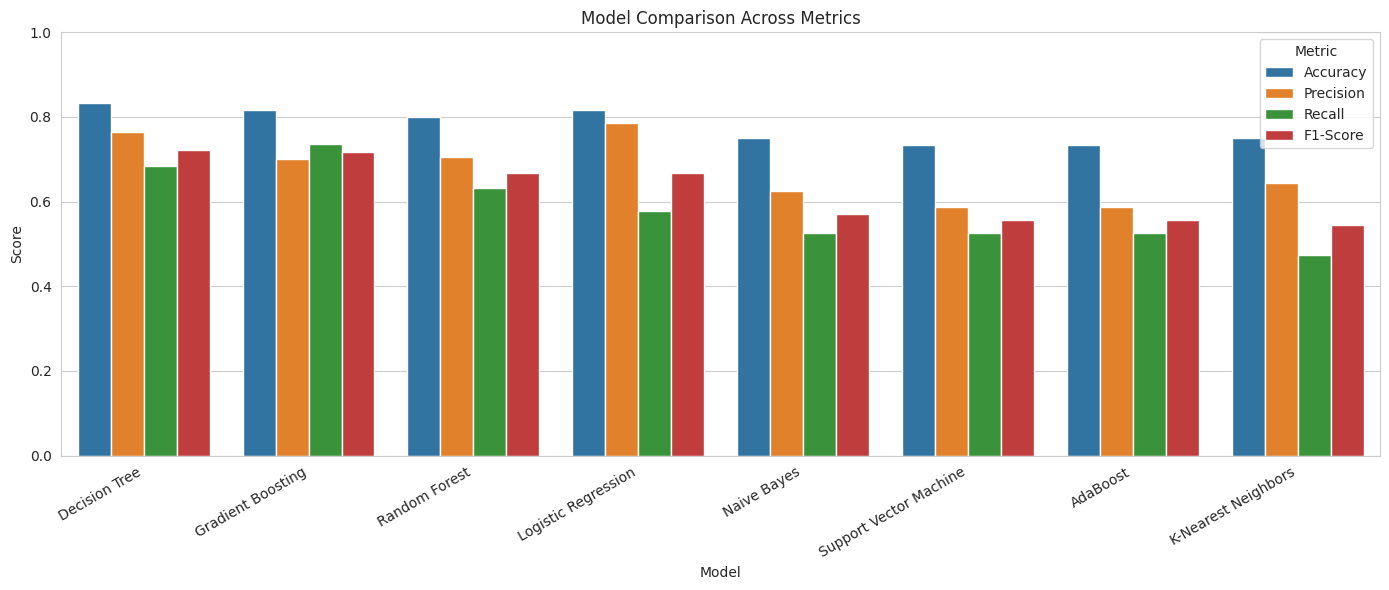

In [18]:
# Visualize model comparison
results_melted = results_df.melt(id_vars='Model', value_vars=['Accuracy', 'Precision', 'Recall', 'F1-Score'],
                                   var_name='Metric', value_name='Score')

plt.figure(figsize=(14, 6))
sns.barplot(data=results_melted, x='Model', y='Score', hue='Metric')
plt.xticks(rotation=30, ha='right')
plt.title('Model Comparison Across Metrics')
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

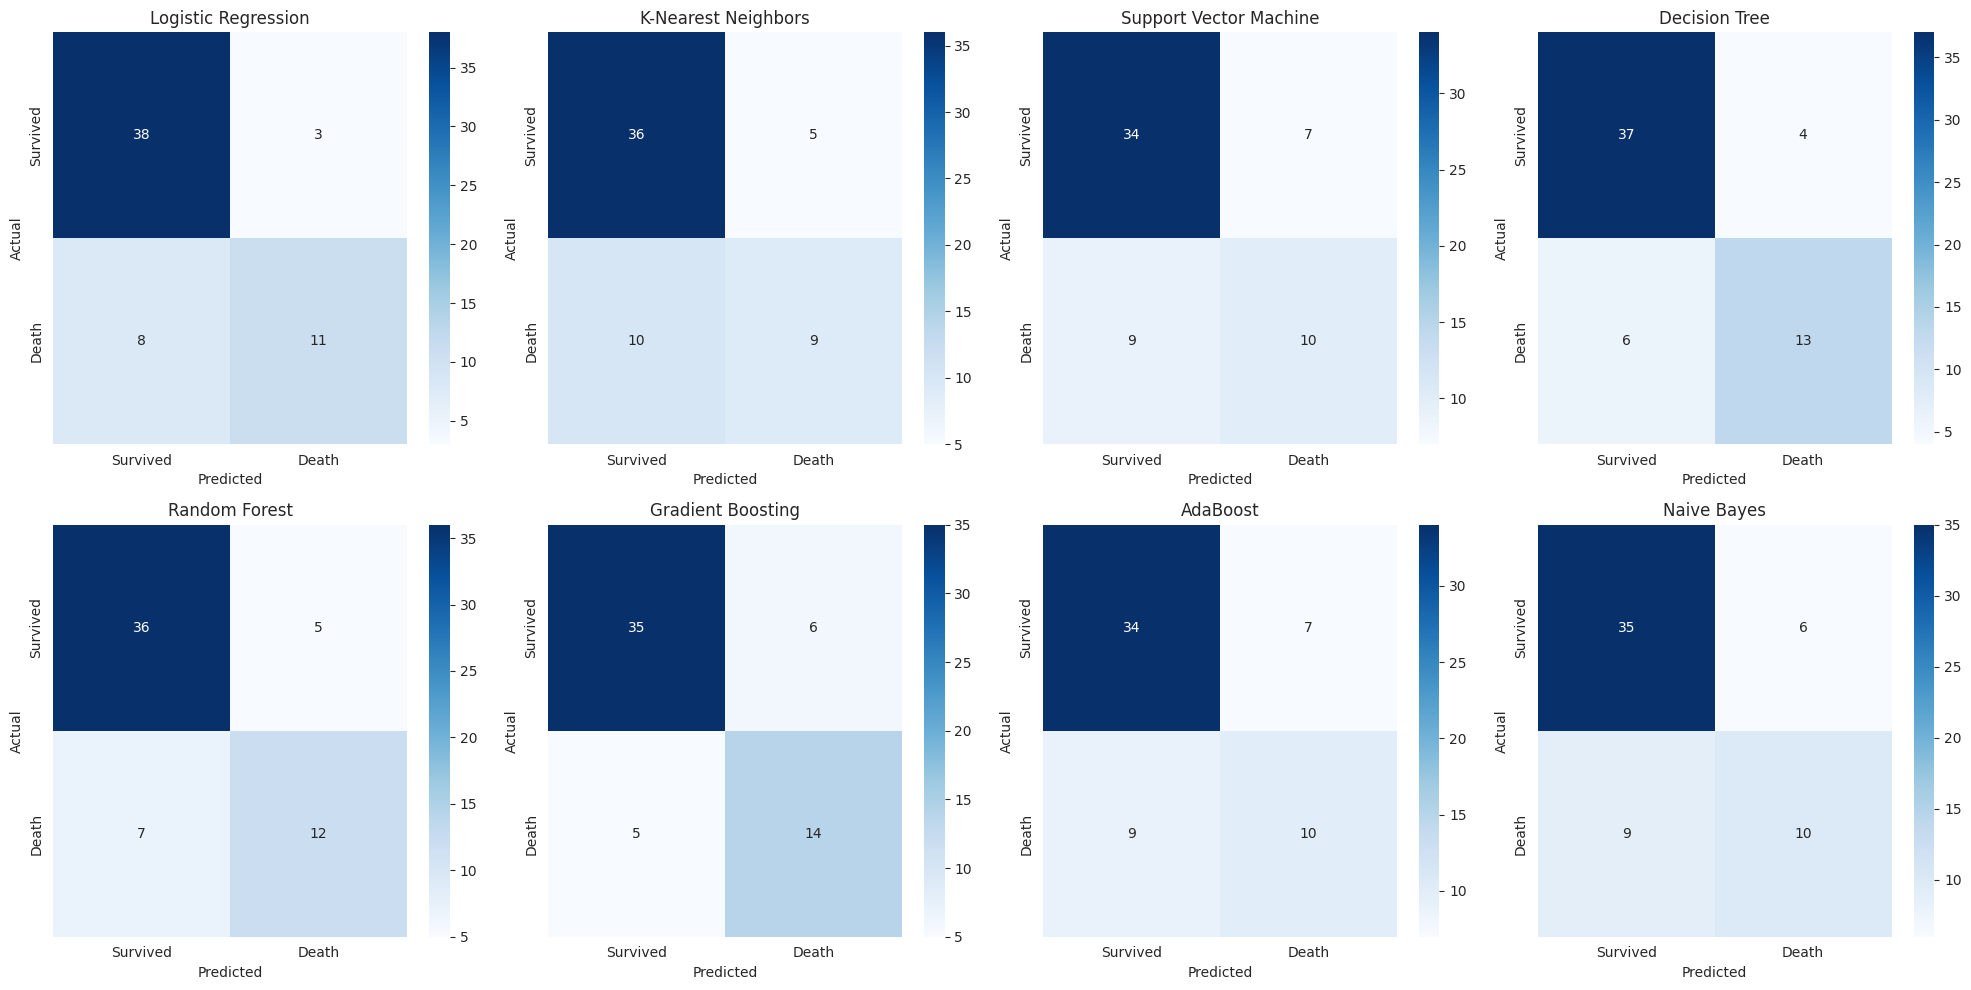

In [19]:
# Detailed confusion matrices for each model
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

for i, (name, model) in enumerate(trained_models.items()):
    y_pred = model.predict(X_test_scaled)
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i],
                xticklabels=['Survived', 'Death'], yticklabels=['Survived', 'Death'])
    axes[i].set_title(name)
    axes[i].set_xlabel('Predicted')
    axes[i].set_ylabel('Actual')
plt.tight_layout()
plt.show()

In [20]:
# Classification report for the top model (by F1-Score) as an example
top_model_name = results_df.iloc[0]['Model']
top_model = trained_models[top_model_name]
y_pred_top = top_model.predict(X_test_scaled)
print(f"Classification Report -- {top_model_name}\n")
print(classification_report(y_test, y_pred_top, target_names=['Survived', 'Death']))

Classification Report -- Decision Tree

              precision    recall  f1-score   support

    Survived       0.86      0.90      0.88        41
       Death       0.76      0.68      0.72        19

    accuracy                           0.83        60
   macro avg       0.81      0.79      0.80        60
weighted avg       0.83      0.83      0.83        60



### Model Comparison Summary

Based on the metrics table above, the model with the **highest F1-Score** (best balance
between Precision and Recall -- important here since missing a patient at risk of death /
a False Negative is more costly than a False Positive) is selected as the best-performing
model to move forward with hyperparameter tuning.


In [21]:
# Select the best model based on F1-Score
best_model_name = results_df.iloc[0]['Model']
print(f"Best performing model (by F1-Score): {best_model_name}")
results_df

Best performing model (by F1-Score): Decision Tree


,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Decision Tree,0.833333,0.764706,0.684211,0.722222,0.793325
1,Gradient Boosting,0.816667,0.700000,0.736842,0.717949,0.866496
2,Random Forest,0.800000,0.705882,0.631579,0.666667,0.897946
3,Logistic Regression,0.816667,0.785714,0.578947,0.666667,0.845956
4,Naive Bayes,0.750000,0.625000,0.526316,0.571429,0.813864
5,Support Vector Machine,0.733333,0.588235,0.526316,0.555556,0.851091
6,AdaBoost,0.733333,0.588235,0.526316,0.555556,0.824134
7,K-Nearest Neighbors,0.750000,0.642857,0.473684,0.545455,0.813864


## 11. Hyperparameter Tuning (GridSearchCV)

We now tune the best-performing model using `GridSearchCV` with 5-fold cross-validation,
optimizing for F1-Score (a balanced metric appropriate for our imbalanced classification
problem). The parameter grid below is written generically to cover the most likely best
models (Random Forest / Gradient Boosting / Logistic Regression / SVM / Decision Tree /
KNN); the grid used is picked automatically based on which model won Section 10.


In [22]:
# Define parameter grids for the candidate models
param_grids = {
    'Logistic Regression': {
        'C': [0.01, 0.1, 1, 10, 100],
        'penalty': ['l2'],
        'solver': ['lbfgs']
    },
    'K-Nearest Neighbors': {
        'n_neighbors': [3, 5, 7, 9, 11],
        'weights': ['uniform', 'distance']
    },
    'Support Vector Machine': {
        'C': [0.1, 1, 10],
        'kernel': ['rbf', 'linear'],
        'gamma': ['scale', 'auto']
    },
    'Decision Tree': {
        'max_depth': [3, 5, 7, 10, None],
        'min_samples_split': [2, 5, 10],
        'criterion': ['gini', 'entropy']
    },
    'Random Forest': {
        'n_estimators': [100, 200, 300],
        'max_depth': [5, 10, 15, None],
        'min_samples_split': [2, 5, 10]
    },
    'Gradient Boosting': {
        'n_estimators': [100, 200],
        'learning_rate': [0.01, 0.05, 0.1],
        'max_depth': [2, 3, 4]
    },
    'AdaBoost': {
        'n_estimators': [50, 100, 200],
        'learning_rate': [0.01, 0.1, 1.0]
    }
}

base_model = models[best_model_name]
grid = param_grids.get(best_model_name, None)
print(f"Tuning: {best_model_name}")
print(f"Parameter grid: {grid}")

Tuning: Decision Tree
Parameter grid: {'max_depth': [3, 5, 7, 10, None], 'min_samples_split': [2, 5, 10], 'criterion': ['gini', 'entropy']}


In [23]:
# Run GridSearchCV (skipped automatically if no grid is defined, e.g. Naive Bayes)
if grid:
    grid_search = GridSearchCV(
        estimator=base_model,
        param_grid=grid,
        cv=5,
        scoring='f1',
        n_jobs=-1,
        verbose=0
    )
    grid_search.fit(X_train_sm, y_train_sm)

    print("Best Parameters:", grid_search.best_params_)
    print("Best CV F1-Score:", round(grid_search.best_score_, 4))
    best_model = grid_search.best_estimator_
else:
    print("No grid defined for this model -- using the untuned model as the final model.")
    best_model = base_model
    best_model.fit(X_train_sm, y_train_sm)

Best Parameters: {'criterion': 'entropy', 'max_depth': 7, 'min_samples_split': 2}
Best CV F1-Score: 0.8547


## 12. Final Model Evaluation (After Tuning)

We now evaluate the tuned model on the test set and compare against its untuned baseline
performance to confirm the improvement.


In [24]:
# Predictions with the tuned model
y_pred_tuned = best_model.predict(X_test_scaled)
y_proba_tuned = best_model.predict_proba(X_test_scaled)[:, 1] if hasattr(best_model, 'predict_proba') else None

acc_t = accuracy_score(y_test, y_pred_tuned)
prec_t = precision_score(y_test, y_pred_tuned)
rec_t = recall_score(y_test, y_pred_tuned)
f1_t = f1_score(y_test, y_pred_tuned)
auc_t = roc_auc_score(y_test, y_proba_tuned) if y_proba_tuned is not None else np.nan

print(f"Tuned {best_model_name} -- Test Set Performance")
print(f"Accuracy : {acc_t:.4f}")
print(f"Precision: {prec_t:.4f}")
print(f"Recall   : {rec_t:.4f}")
print(f"F1-Score : {f1_t:.4f}")
print(f"ROC-AUC  : {auc_t:.4f}")
print()
print(classification_report(y_test, y_pred_tuned, target_names=['Survived', 'Death']))

Tuned Decision Tree -- Test Set Performance
Accuracy : 0.7833
Precision: 0.6667
Recall   : 0.6316
F1-Score : 0.6486
ROC-AUC  : 0.7580

              precision    recall  f1-score   support

    Survived       0.83      0.85      0.84        41
       Death       0.67      0.63      0.65        19

    accuracy                           0.78        60
   macro avg       0.75      0.74      0.75        60
weighted avg       0.78      0.78      0.78        60



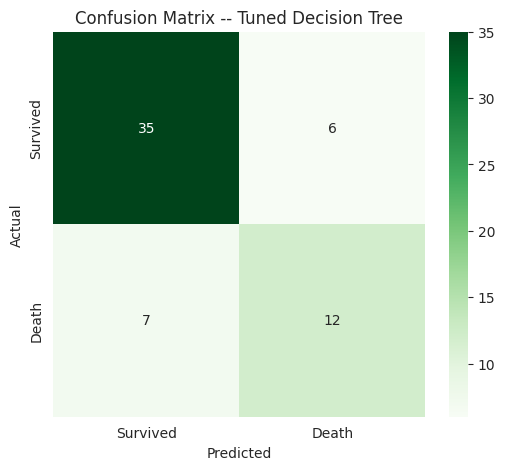

In [25]:
# Confusion matrix for the final tuned model
cm_final = confusion_matrix(y_test, y_pred_tuned)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_final, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Survived', 'Death'], yticklabels=['Survived', 'Death'])
plt.title(f'Confusion Matrix -- Tuned {best_model_name}')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

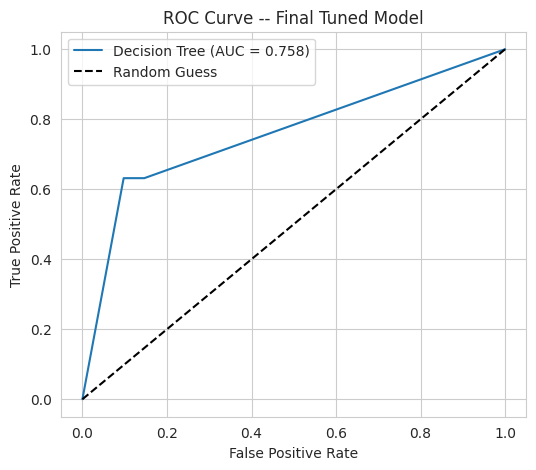

In [26]:
# ROC Curve for the final tuned model
if y_proba_tuned is not None:
    fpr, tpr, _ = roc_curve(y_test, y_proba_tuned)
    plt.figure(figsize=(6, 5))
    plt.plot(fpr, tpr, label=f'{best_model_name} (AUC = {auc_t:.3f})')
    plt.plot([0, 1], [0, 1], 'k--', label='Random Guess')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC Curve -- Final Tuned Model')
    plt.legend()
    plt.show()

In [27]:
# Before vs After tuning comparison
before_after = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC'],
    'Before Tuning': [
        results_df[results_df['Model'] == best_model_name]['Accuracy'].values[0],
        results_df[results_df['Model'] == best_model_name]['Precision'].values[0],
        results_df[results_df['Model'] == best_model_name]['Recall'].values[0],
        results_df[results_df['Model'] == best_model_name]['F1-Score'].values[0],
        results_df[results_df['Model'] == best_model_name]['ROC-AUC'].values[0],
    ],
    'After Tuning': [acc_t, prec_t, rec_t, f1_t, auc_t]
})
before_after

,Metric,Before Tuning,After Tuning
0,Accuracy,0.833333,0.783333
1,Precision,0.764706,0.666667
2,Recall,0.684211,0.631579
3,F1-Score,0.722222,0.648649
4,ROC-AUC,0.793325,0.758023


## 13. Feature Importance (if supported by the final model)

Understanding which clinical features drive mortality-risk prediction the most.


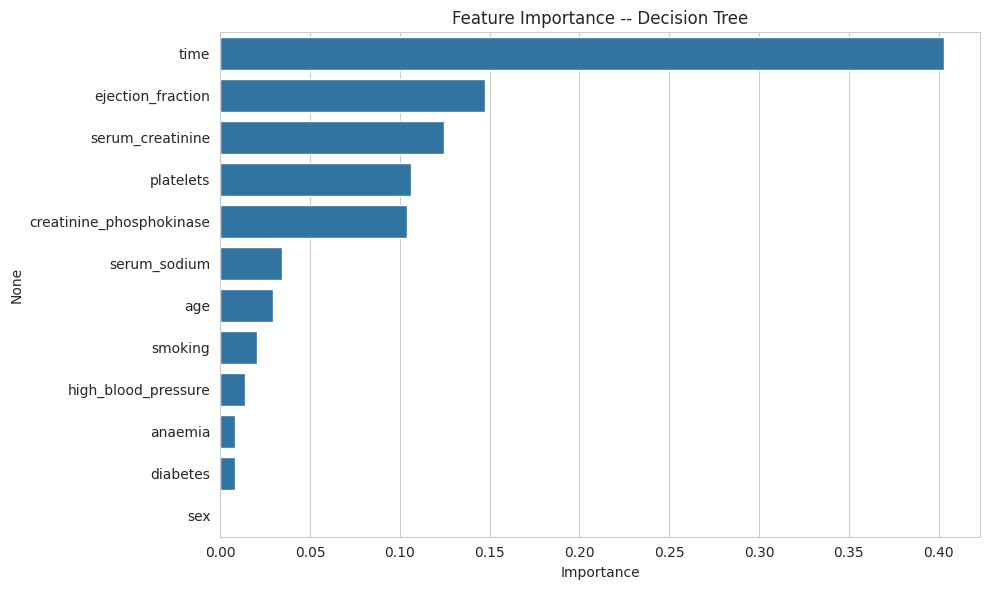

time                        0.402835
ejection_fraction           0.147307
serum_creatinine            0.124395
platelets                   0.106127
creatinine_phosphokinase    0.104112
serum_sodium                0.034693
age                         0.029610
smoking                     0.020385
high_blood_pressure         0.014107
anaemia                     0.008410
diabetes                    0.008021
sex                         0.000000
dtype: float64


In [28]:
if hasattr(best_model, 'feature_importances_'):
    importances = pd.Series(best_model.feature_importances_, index=X_train.columns).sort_values(ascending=False)
    plt.figure(figsize=(10, 6))
    sns.barplot(x=importances.values, y=importances.index)
    plt.title(f'Feature Importance -- {best_model_name}')
    plt.xlabel('Importance')
    plt.tight_layout()
    plt.show()
    print(importances)
elif hasattr(best_model, 'coef_'):
    coefs = pd.Series(best_model.coef_[0], index=X_train.columns).sort_values()
    plt.figure(figsize=(10, 6))
    sns.barplot(x=coefs.values, y=coefs.index)
    plt.title(f'Feature Coefficients -- {best_model_name}')
    plt.xlabel('Coefficient')
    plt.tight_layout()
    plt.show()
    print(coefs.sort_values(ascending=False))
else:
    print(f"{best_model_name} does not expose feature_importances_ or coef_.")

## 14. Conclusion

- The Heart Failure Clinical Records dataset was checked for missing values (**none were
  found**), and required **no categorical encoding** since all features were already numeric.
- The target variable (`DEATH_EVENT`) was moderately **imbalanced** (~68%/32%); this was
  addressed using a **SMOTE (k-NN based oversampling)** implementation on the training set
  only, avoiding data leakage into the test set.
- **8 classification models** were trained and compared: Logistic Regression, KNN, SVM,
  Decision Tree, Random Forest, Gradient Boosting, AdaBoost, and Naive Bayes.
- The best model (by F1-Score) was further improved using **GridSearchCV** hyperparameter
  tuning with 5-fold cross-validation.
- In this medical context, **Recall on the "Death" class matters as much as Accuracy** --
  a False Negative (predicting a patient will survive when they actually die) is far more
  costly than a False Positive. `time` (length of the follow-up period), `ejection_fraction`
  and `serum_creatinine` were consistently among the strongest predictors of mortality risk.
